In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("D:/customer_churn_ml/data/telco.csv")

# Clean column names (important!)
df.columns = df.columns.str.strip()

df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [3]:
df.shape

(7043, 50)

In [4]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='str')

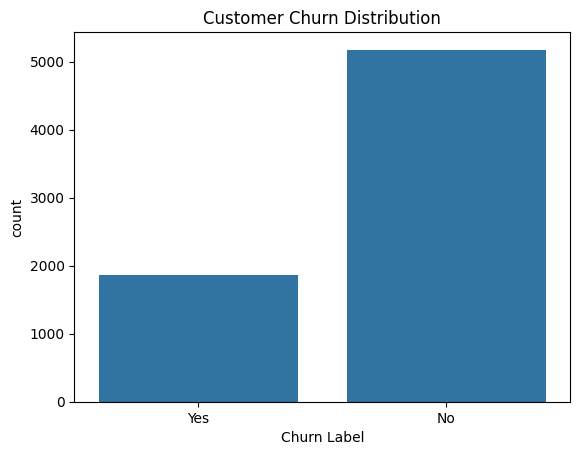

In [5]:
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [6]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

Churn Reason      5174
Churn Category    5174
Offer             3877
Internet Type     1526
Senior Citizen       0
Married              0
Age                  0
Under 30             0
Country              0
State                0
dtype: int64

In [8]:
leakage_cols = [
    "Customer ID",
    "Customer Status",
    "Churn Category",
    "Churn Reason",
    "Churn Score"
]

df_model = df.drop(columns=leakage_cols)

In [9]:
df_model.head()

,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,CLTV
0,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,...,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Yes,5433
1,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,...,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Yes,5302
2,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,...,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Yes,3179
3,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,...,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Yes,5337
4,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,...,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Yes,2793


In [10]:
df_model = df_model.dropna()
df_model.shape

(2493, 45)